In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math as math
import seaborn as sns 

In [2]:

data_filtered = pd.read_csv('../../data/Berrocal_2020/Data/eve_data_longform_w_nuclei_060520_FILTERED.csv', header=0)
print(data_filtered)

        Unnamed: 0  nucleus_id  particle_id  set_id    ap_raw  ap_registered  \
0              192      1.0517          NaN       1  0.417799       0.412853   
1              193      1.0517          NaN       1  0.415974       0.411356   
2              194      1.0517          NaN       1  0.414500       0.410133   
3              195      1.0517          NaN       1  0.414155       0.410011   
4              196      1.0517          NaN       1  0.414665       0.410521   
...            ...         ...          ...     ...       ...            ...   
430068      497451     11.1492          NaN      11  0.274391       0.290641   
430069      497452     11.1492          NaN      11  0.274822       0.291048   
430070      497453     11.1492          NaN      11  0.275375       0.291569   
430071      497454     11.1492          NaN      11  0.276047       0.292204   
430072      497455     11.1492          NaN      11  0.276220       0.292367   

              xPos        yPos  burst_s

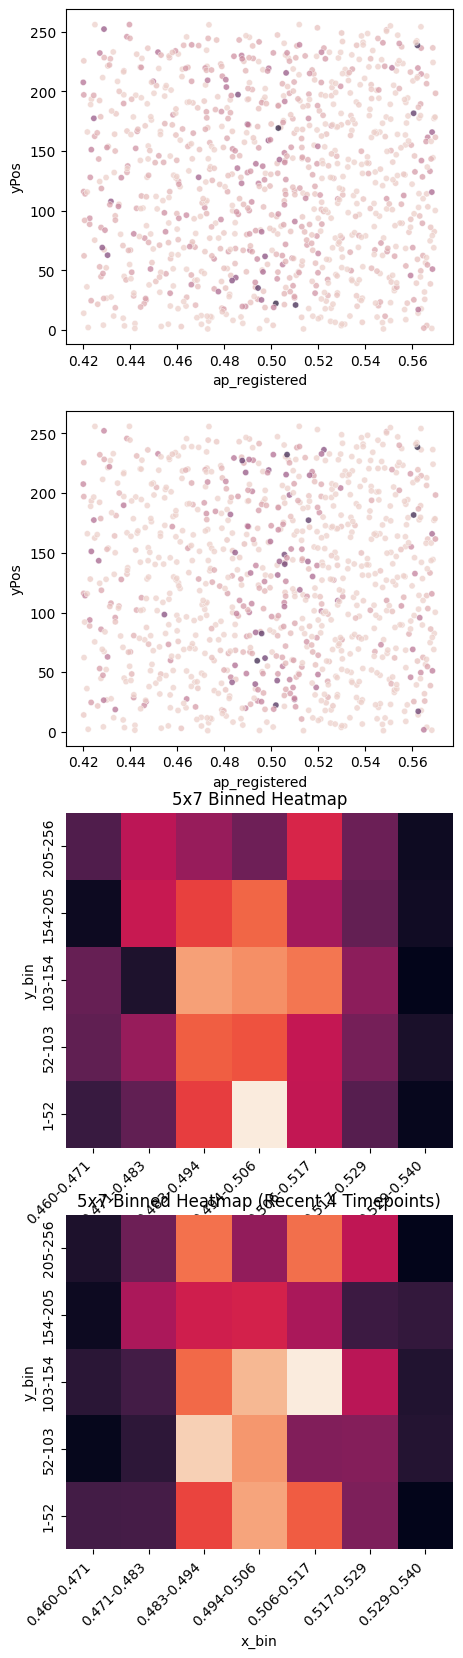

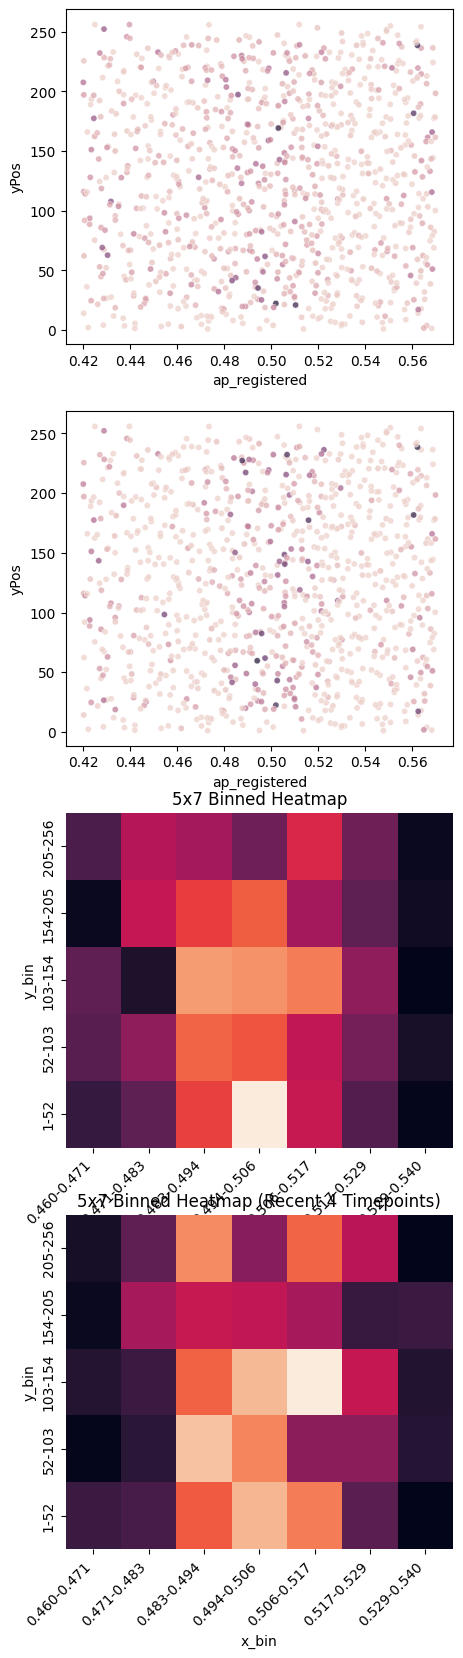

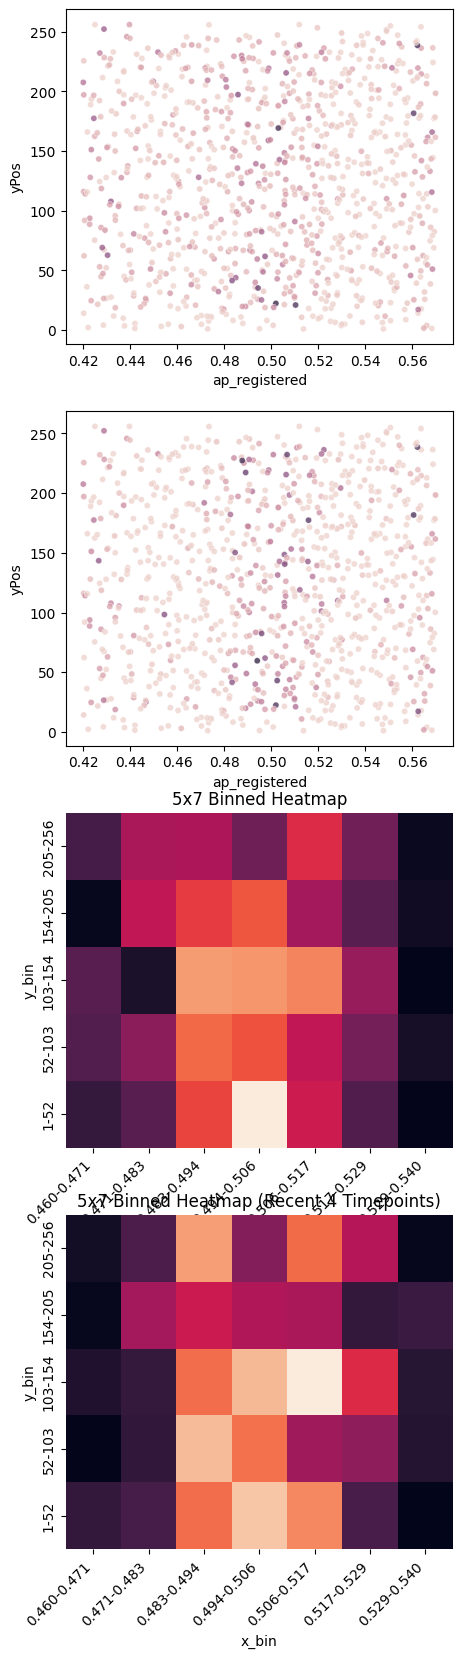

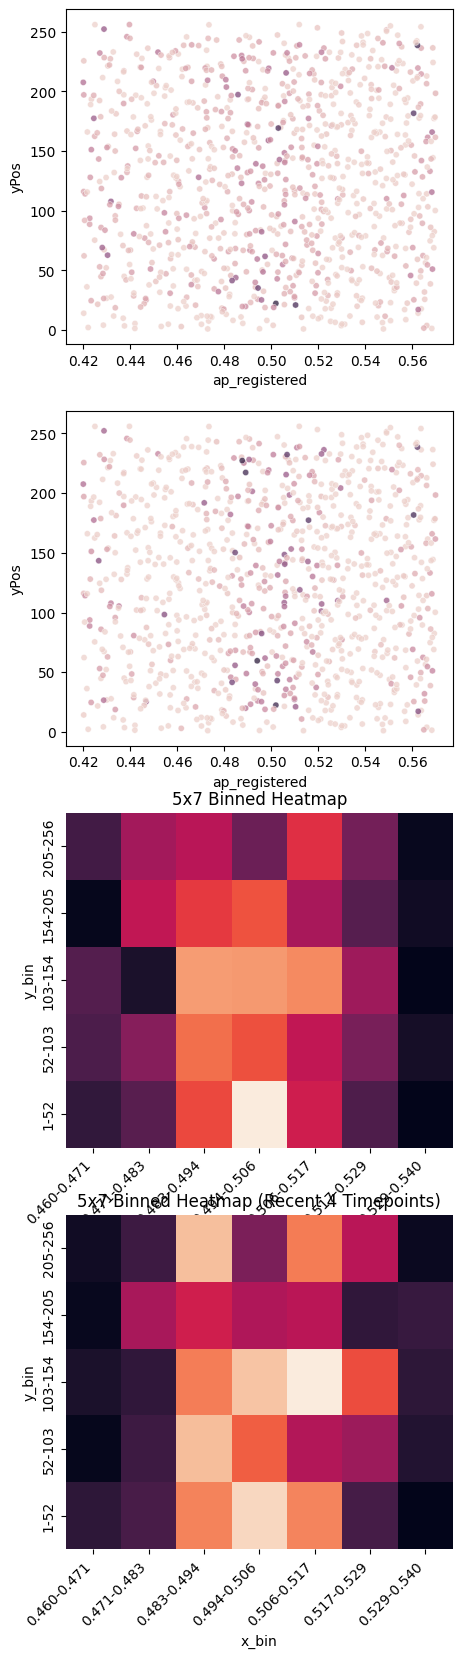

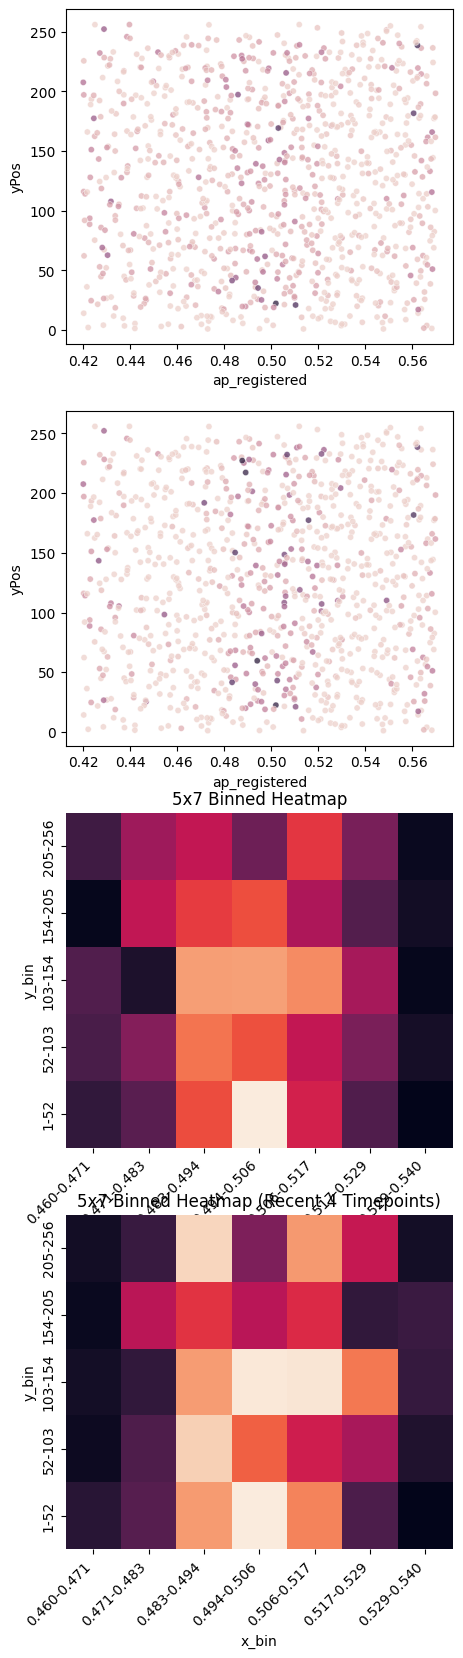

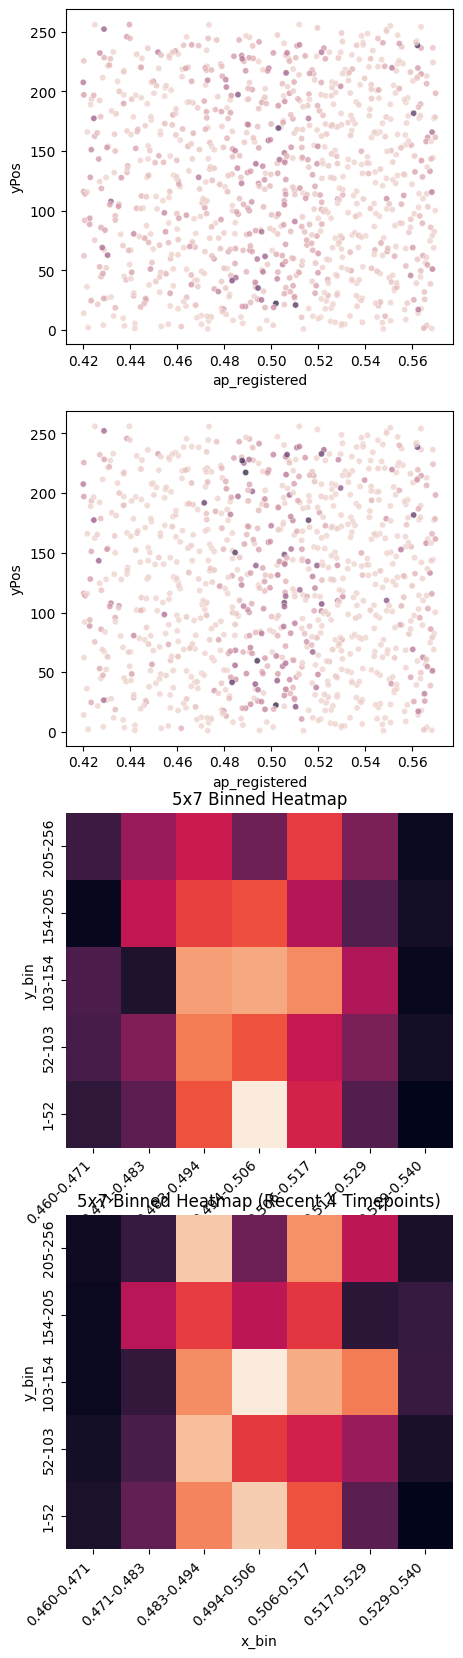

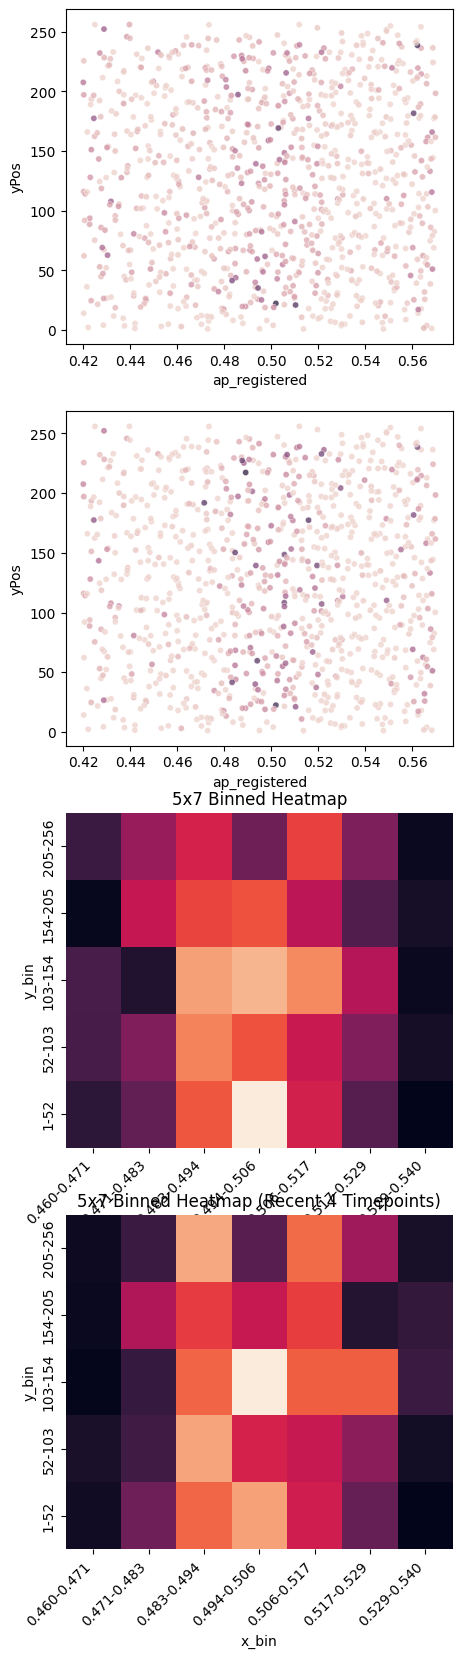

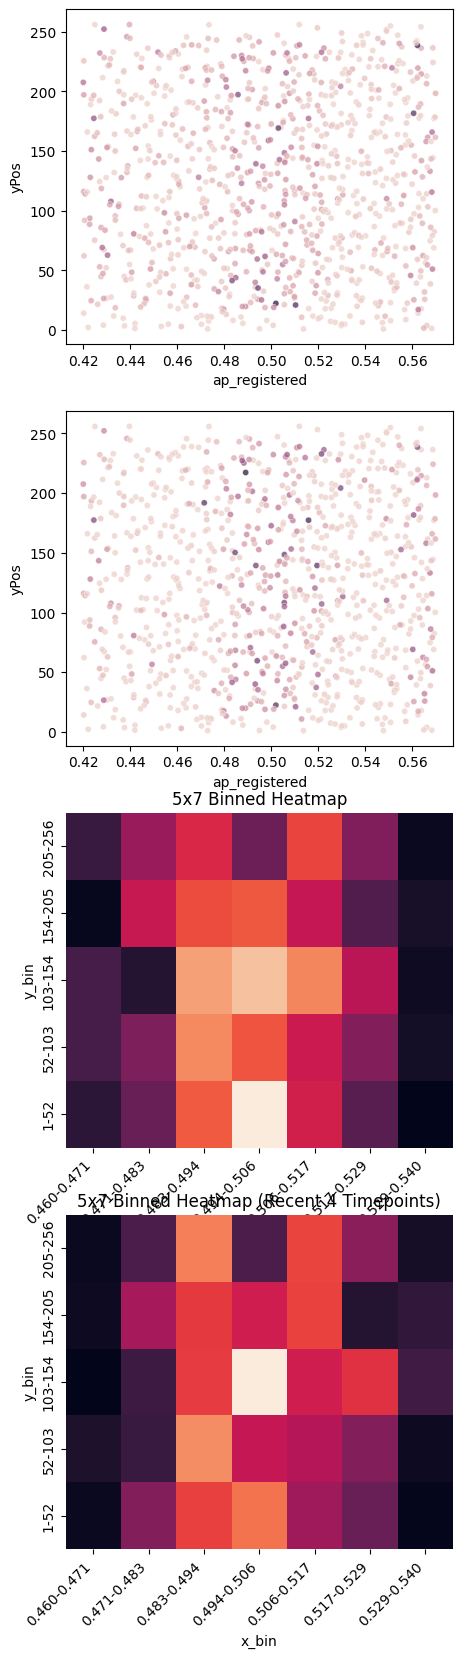

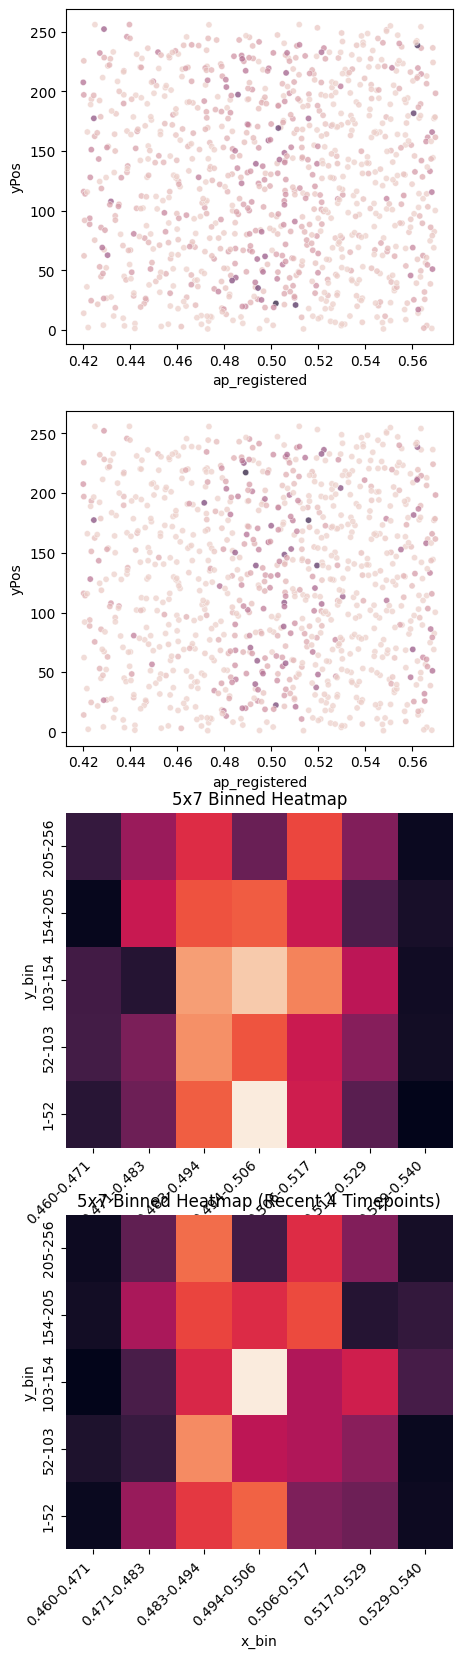

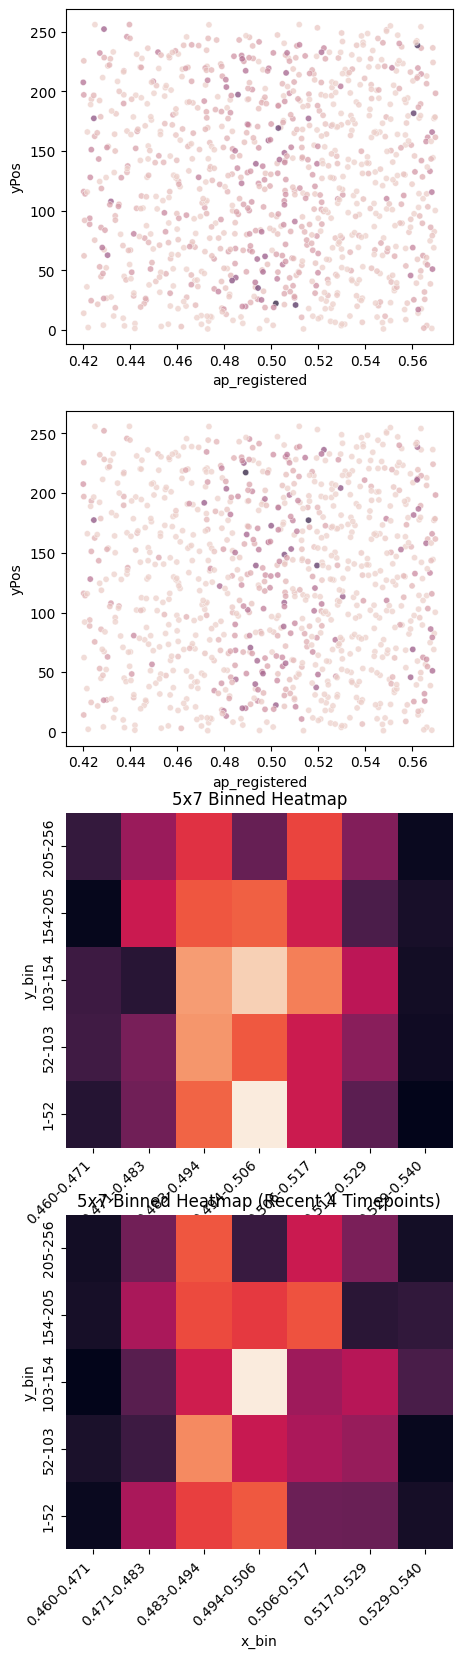

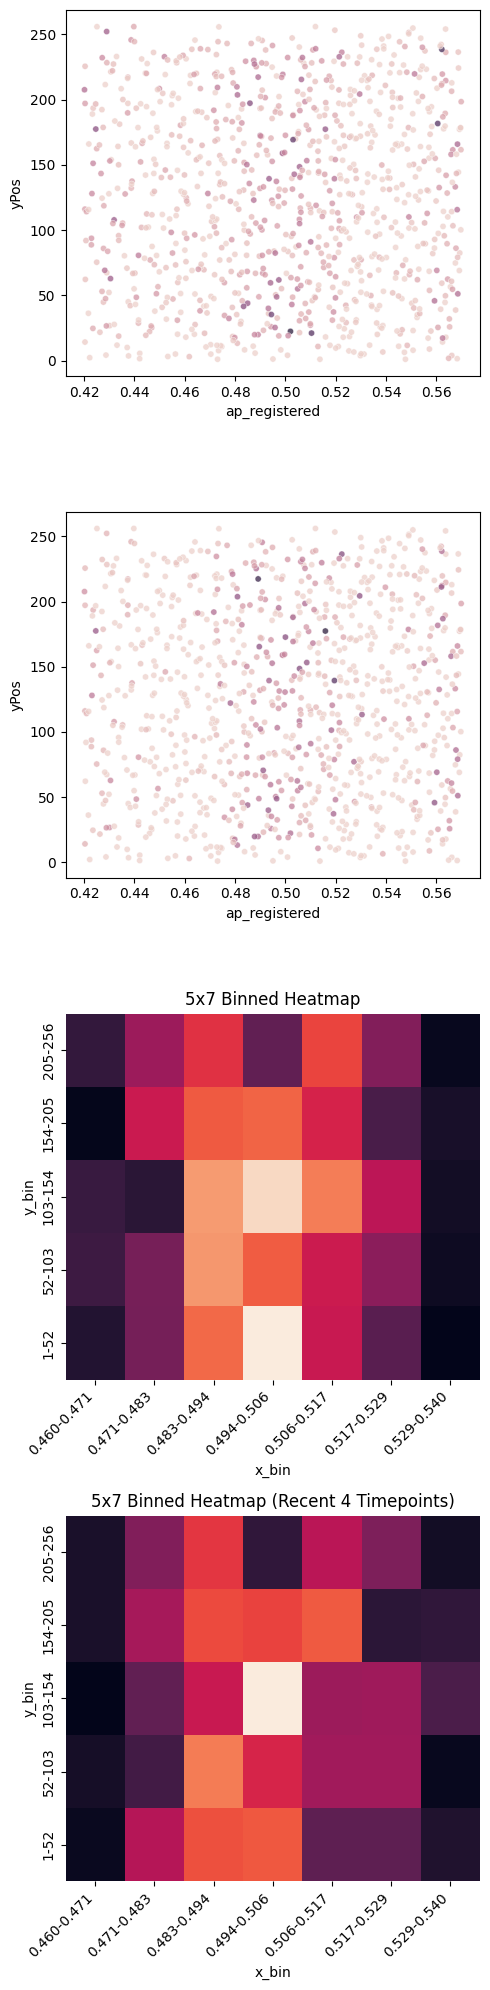

In [9]:
fluo_traces = data_filtered.pivot(index='nucleus_id', columns='time', values=['fluo'])
fluo_traces['ap_registered'] = data_filtered.pivot(index='nucleus_id', columns='time', values=['ap_registered']).mean(axis=1)
fluo_traces['yPos'] = data_filtered.pivot(index='nucleus_id', columns='time', values=['yPos']).mean(axis=1)
fluo_traces = fluo_traces.fillna(0)
fluo_traces.reset_index(inplace=True)
fluo_traces = fluo_traces[(fluo_traces['ap_registered'] >= 0.42) & (fluo_traces['ap_registered'] <= 0.57)]

# Loop over the time points and plot in each subplot
for i, t in enumerate(range(1100, 1301, 20)):
    fig, axes = plt.subplots(4, 1, figsize=(5, 20))
    axes = axes.flatten()
    sns.scatterplot(data=fluo_traces, x="ap_registered", y="yPos", hue=fluo_traces['fluo'].iloc[:,:fluo_traces['fluo'].columns.tolist().index(t)+1].sum(axis=1), legend=False, ax=axes[0],s=20,alpha=0.75)
    sns.scatterplot(data=fluo_traces, x="ap_registered", y="yPos", hue=fluo_traces['fluo'].iloc[:,fluo_traces['fluo'].columns.tolist().index(t)-3:fluo_traces['fluo'].columns.tolist().index(t)+1].sum(axis=1), legend=False, ax=axes[1],s=20,alpha=0.75)
    # bin the :index(t) fluo into 5x7 grid and plot a heatmap
    x_bins = np.linspace(0.46, 0.54, 8)
    y_bins = np.linspace(fluo_traces['yPos'].min(), fluo_traces['yPos'].max(), 6)
    fluo_traces['x_bin'] = pd.cut(fluo_traces['ap_registered'], bins=x_bins, labels=False)
    fluo_traces['y_bin'] = pd.cut(fluo_traces['yPos'], bins=y_bins, labels=False)
    heatmap_data = fluo_traces.groupby(['x_bin', 'y_bin']).apply(lambda df: df['fluo'].iloc[:,:fluo_traces['fluo'].columns.tolist().index(t)+1].sum(axis=1).sum()).unstack().fillna(0)
    sns.heatmap(heatmap_data.T, ax=axes[2], cbar=False)
    axes[2].invert_yaxis()
    # Ensure heatmaps are oriented as 5 rows (y bins) x 7 cols (x bins)
    n_rows = len(y_bins) - 1
    n_cols = len(x_bins) - 1

    # axes[2] uses heatmap_data.T (should be n_rows x n_cols)
    hm = heatmap_data.T
    xtick_pos = np.arange(hm.shape[1]) + 0.5
    ytick_pos = np.arange(hm.shape[0]) + 0.5
    x_labels = [f'{start:.3f}-{end:.3f}' for start, end in zip(x_bins[:-1], x_bins[1:])]
    y_labels = [f'{int(start)}-{int(end)}' for start, end in zip(y_bins[:-1], y_bins[1:])]

    axes[2].set_xticks(xtick_pos)
    axes[2].set_xticklabels(x_labels, rotation=45, ha='right')
    axes[2].set_yticks(ytick_pos)
    axes[2].set_yticklabels(y_labels)
    axes[2].set_title('5x7 Binned Heatmap')

    heatmap_data = fluo_traces.groupby(['x_bin', 'y_bin']).apply(lambda df: df['fluo'].iloc[:,fluo_traces['fluo'].columns.tolist().index(t)-3:fluo_traces['fluo'].columns.tolist().index(t)+1].sum(axis=1).sum()).unstack().fillna(0)
    sns.heatmap(heatmap_data.T, ax=axes[3], cbar=False)
    axes[3].invert_yaxis()
    # Ensure heatmaps are oriented as 5 rows (y bins) x 7 cols (x bins)
    n_rows = len(y_bins) - 1
    n_cols = len(x_bins) - 1

    # axes[2] uses heatmap_data.T (should be n_rows x n_cols)
    hm = heatmap_data.T
    xtick_pos = np.arange(hm.shape[1]) + 0.5
    ytick_pos = np.arange(hm.shape[0]) + 0.5
    x_labels = [f'{start:.3f}-{end:.3f}' for start, end in zip(x_bins[:-1], x_bins[1:])]
    y_labels = [f'{int(start)}-{int(end)}' for start, end in zip(y_bins[:-1], y_bins[1:])]

    axes[3].set_xticks(xtick_pos)
    axes[3].set_xticklabels(x_labels, rotation=45, ha='right')
    axes[3].set_yticks(ytick_pos)
    axes[3].set_yticklabels(y_labels)
    axes[3].set_title('5x7 Binned Heatmap (Recent 4 Timepoints)')
                           

plt.tight_layout()

## Add global axis labels
#fig.text(0.5, 0.02, 'AP Registered', ha='center', fontsize=14)
#fig.text(0.02, 0.5, 'Y Position', va='center', rotation='vertical', fontsize=14)

plt.show()

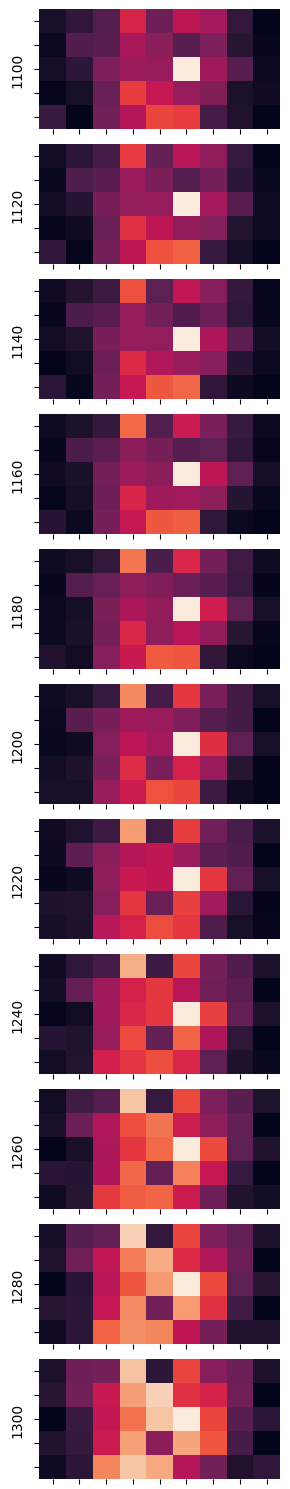

In [18]:
fluo_traces = data_filtered.pivot(index='nucleus_id', columns='time', values=['fluo'])
fluo_traces['ap_registered'] = data_filtered.pivot(index='nucleus_id', columns='time', values=['ap_registered']).mean(axis=1)
fluo_traces['yPos'] = data_filtered.pivot(index='nucleus_id', columns='time', values=['yPos']).mean(axis=1)
fluo_traces = fluo_traces.fillna(0)
fluo_traces.reset_index(inplace=True)
fluo_traces = fluo_traces[(fluo_traces['ap_registered'] >= 0.42) & (fluo_traces['ap_registered'] <= 0.57)]

fig, axes = plt.subplots(len(range(1100, 1301, 20)), 1, figsize=(3, 15))
axes = axes.flatten()
# Loop over the time points and plot in each subplot
for i, t in enumerate(range(1100, 1301, 20)):
    #sns.scatterplot(data=fluo_traces, x="ap_registered", y="yPos", hue=fluo_traces['fluo'].iloc[:,:fluo_traces['fluo'].columns.tolist().index(t)+1].sum(axis=1), legend=False, ax=axes[0],s=20,alpha=0.75)
    #sns.scatterplot(data=fluo_traces, x="ap_registered", y="yPos", hue=fluo_traces['fluo'].iloc[:,fluo_traces['fluo'].columns.tolist().index(t)-3:fluo_traces['fluo'].columns.tolist().index(t)+1].sum(axis=1), legend=False, ax=axes[1],s=20,alpha=0.75)
    # bin the :index(t) fluo into 5x7 grid and plot a heatmap
    x_bins = np.linspace(0.46, 0.54, 10)
    y_bins = np.linspace(fluo_traces['yPos'].min(), fluo_traces['yPos'].max(), 6)
    fluo_traces['x_bin'] = pd.cut(fluo_traces['ap_registered'], bins=x_bins, labels=False)
    fluo_traces['y_bin'] = pd.cut(fluo_traces['yPos'], bins=y_bins, labels=False)
    #heatmap_data = fluo_traces.groupby(['x_bin', 'y_bin']).apply(lambda df: df['fluo'].iloc[:,:fluo_traces['fluo'].columns.tolist().index(t)+1].sum(axis=1).sum()).unstack().fillna(0)
    #sns.heatmap(heatmap_data.T, ax=axes[2], cbar=False)
    #axes[2].invert_yaxis()
    # Ensure heatmaps are oriented as 5 rows (y bins) x 7 cols (x bins)
    #n_rows = len(y_bins) - 1
    #n_cols = len(x_bins) - 1

    ## axes[2] uses heatmap_data.T (should be n_rows x n_cols)
    #hm = heatmap_data.T
    #xtick_pos = np.arange(hm.shape[1]) + 0.5
    #ytick_pos = np.arange(hm.shape[0]) + 0.5
    #x_labels = [f'{start:.3f}-{end:.3f}' for start, end in zip(x_bins[:-1], x_bins[1:])]
    #y_labels = [f'{int(start)}-{int(end)}' for start, end in zip(y_bins[:-1], y_bins[1:])]

    #axes[2].set_xticks(xtick_pos)
    #axes[2].set_xticklabels(x_labels, rotation=45, ha='right')
    #axes[2].set_yticks(ytick_pos)
    #axes[2].set_yticklabels(y_labels)
    #axes[2].set_title('5x7 Binned Heatmap')

    heatmap_data = fluo_traces.groupby(['x_bin', 'y_bin']).apply(lambda df: df['fluo'].iloc[:,fluo_traces['fluo'].columns.tolist().index(t)-3:fluo_traces['fluo'].columns.tolist().index(t)+1].sum(axis=1).sum()).unstack().fillna(0)
    sns.heatmap(heatmap_data.T, ax=axes[i], cbar=False)
    axes[i].invert_yaxis()
    # Ensure heatmaps are oriented as 5 rows (y bins) x 7 cols (x bins)
    n_rows = len(y_bins) - 1
    n_cols = len(x_bins) - 1

    # axes[2] uses heatmap_data.T (should be n_rows x n_cols)
    hm = heatmap_data.T
    xtick_pos = np.arange(hm.shape[1]) + 0.5
    ytick_pos = np.arange(hm.shape[0]) + 0.5
    x_labels = [f'{start:.3f}-{end:.3f}' for start, end in zip(x_bins[:-1], x_bins[1:])]
    y_labels = [f'{int(start)}-{int(end)}' for start, end in zip(y_bins[:-1], y_bins[1:])]

    axes[i].set_xticks(xtick_pos)
    axes[i].set_xticklabels('')#x_labels, rotation=45, ha='right')
    axes[i].set_yticks(ytick_pos)
    axes[i].set_yticklabels('')#y_labels)
    axes[i].set_title('')
    axes[i].set_xlabel('')
    axes[i].set_ylabel(t)
                           

plt.tight_layout()

## Add global axis labels
#fig.text(0.5, 0.02, 'AP Registered', ha='center', fontsize=14)
#fig.text(0.02, 0.5, 'Y Position', va='center', rotation='vertical', fontsize=14)

plt.show()

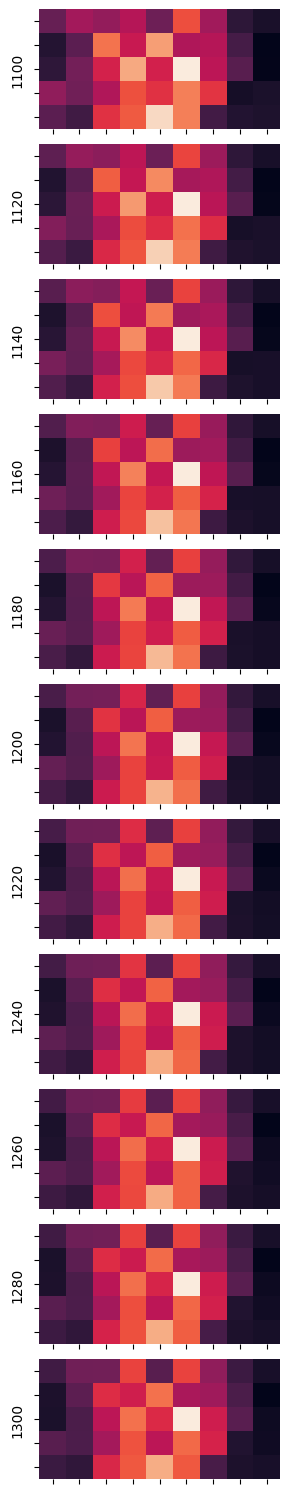

In [17]:
fluo_traces = data_filtered.pivot(index='nucleus_id', columns='time', values=['fluo'])
fluo_traces['ap_registered'] = data_filtered.pivot(index='nucleus_id', columns='time', values=['ap_registered']).mean(axis=1)
fluo_traces['yPos'] = data_filtered.pivot(index='nucleus_id', columns='time', values=['yPos']).mean(axis=1)
fluo_traces = fluo_traces.fillna(0)
fluo_traces.reset_index(inplace=True)
fluo_traces = fluo_traces[(fluo_traces['ap_registered'] >= 0.42) & (fluo_traces['ap_registered'] <= 0.57)]

fig, axes = plt.subplots(len(range(1100, 1301, 20)), 1, figsize=(3, 15))
axes = axes.flatten()
# Loop over the time points and plot in each subplot
for i, t in enumerate(range(1100, 1301, 20)):
    #sns.scatterplot(data=fluo_traces, x="ap_registered", y="yPos", hue=fluo_traces['fluo'].iloc[:,:fluo_traces['fluo'].columns.tolist().index(t)+1].sum(axis=1), legend=False, ax=axes[0],s=20,alpha=0.75)
    #sns.scatterplot(data=fluo_traces, x="ap_registered", y="yPos", hue=fluo_traces['fluo'].iloc[:,fluo_traces['fluo'].columns.tolist().index(t)-3:fluo_traces['fluo'].columns.tolist().index(t)+1].sum(axis=1), legend=False, ax=axes[1],s=20,alpha=0.75)
    # bin the :index(t) fluo into 5x7 grid and plot a heatmap
    x_bins = np.linspace(0.46, 0.54, 10)
    y_bins = np.linspace(fluo_traces['yPos'].min(), fluo_traces['yPos'].max(), 6)
    fluo_traces['x_bin'] = pd.cut(fluo_traces['ap_registered'], bins=x_bins, labels=False)
    fluo_traces['y_bin'] = pd.cut(fluo_traces['yPos'], bins=y_bins, labels=False)
    #heatmap_data = fluo_traces.groupby(['x_bin', 'y_bin']).apply(lambda df: df['fluo'].iloc[:,:fluo_traces['fluo'].columns.tolist().index(t)+1].sum(axis=1).sum()).unstack().fillna(0)
    #sns.heatmap(heatmap_data.T, ax=axes[2], cbar=False)
    #axes[2].invert_yaxis()
    # Ensure heatmaps are oriented as 5 rows (y bins) x 7 cols (x bins)
    #n_rows = len(y_bins) - 1
    #n_cols = len(x_bins) - 1

    ## axes[2] uses heatmap_data.T (should be n_rows x n_cols)
    #hm = heatmap_data.T
    #xtick_pos = np.arange(hm.shape[1]) + 0.5
    #ytick_pos = np.arange(hm.shape[0]) + 0.5
    #x_labels = [f'{start:.3f}-{end:.3f}' for start, end in zip(x_bins[:-1], x_bins[1:])]
    #y_labels = [f'{int(start)}-{int(end)}' for start, end in zip(y_bins[:-1], y_bins[1:])]

    #axes[2].set_xticks(xtick_pos)
    #axes[2].set_xticklabels(x_labels, rotation=45, ha='right')
    #axes[2].set_yticks(ytick_pos)
    #axes[2].set_yticklabels(y_labels)
    #axes[2].set_title('')

    heatmap_data = fluo_traces.groupby(['x_bin', 'y_bin']).apply(lambda df: df['fluo'].iloc[:,:fluo_traces['fluo'].columns.tolist().index(t)+1].sum(axis=1).sum()).unstack().fillna(0)
    sns.heatmap(heatmap_data.T, ax=axes[i], cbar=False)
    axes[i].invert_yaxis()
    # Ensure heatmaps are oriented as 5 rows (y bins) x 7 cols (x bins)
    n_rows = len(y_bins) - 1
    n_cols = len(x_bins) - 1

    # axes[2] uses heatmap_data.T (should be n_rows x n_cols)
    hm = heatmap_data.T
    xtick_pos = np.arange(hm.shape[1]) + 0.5
    ytick_pos = np.arange(hm.shape[0]) + 0.5
    x_labels = [f'{start:.3f}-{end:.3f}' for start, end in zip(x_bins[:-1], x_bins[1:])]
    y_labels = [f'{int(start)}-{int(end)}' for start, end in zip(y_bins[:-1], y_bins[1:])]

    axes[i].set_xticks(xtick_pos)
    axes[i].set_xticklabels('')#x_labels, rotation=45, ha='right')
    axes[i].set_yticks(ytick_pos)
    axes[i].set_yticklabels('')#y_labels)
    axes[i].set_title('')
    axes[i].set_xlabel('')
    axes[i].set_ylabel(t)
                           

plt.tight_layout()

## Add global axis labels
#fig.text(0.5, 0.02, 'AP Registered', ha='center', fontsize=14)
#fig.text(0.02, 0.5, 'Y Position', va='center', rotation='vertical', fontsize=14)

plt.show()

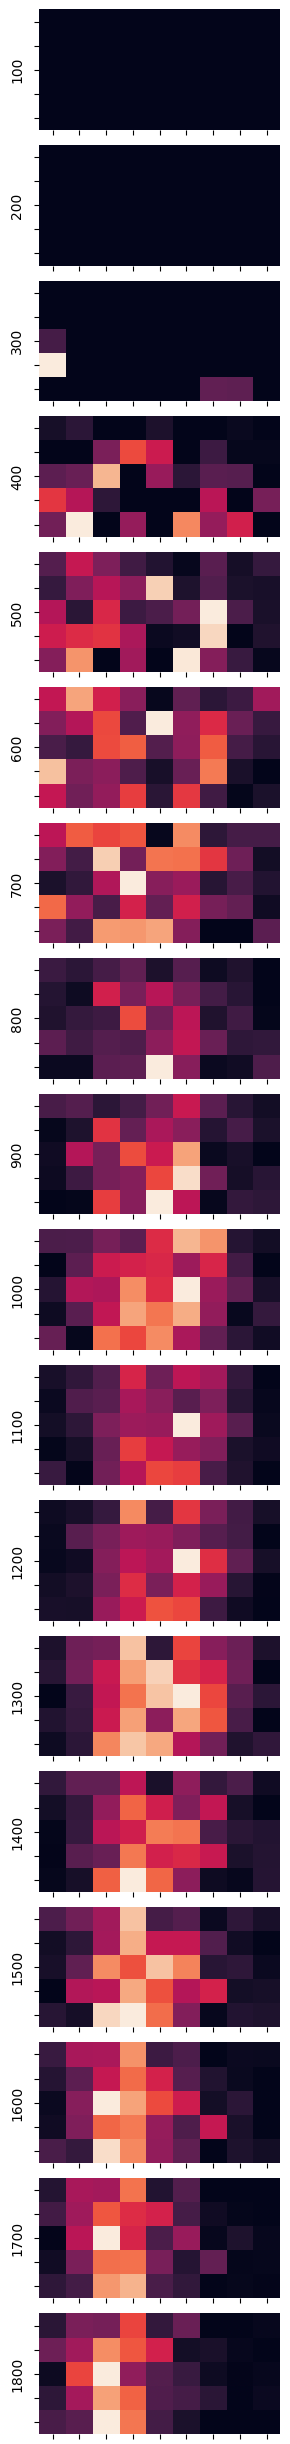

In [19]:
fluo_traces = data_filtered.pivot(index='nucleus_id', columns='time', values=['fluo'])
fluo_traces['ap_registered'] = data_filtered.pivot(index='nucleus_id', columns='time', values=['ap_registered']).mean(axis=1)
fluo_traces['yPos'] = data_filtered.pivot(index='nucleus_id', columns='time', values=['yPos']).mean(axis=1)
fluo_traces = fluo_traces.fillna(0)
fluo_traces.reset_index(inplace=True)
fluo_traces = fluo_traces[(fluo_traces['ap_registered'] >= 0.42) & (fluo_traces['ap_registered'] <= 0.57)]

fig, axes = plt.subplots(len(range(100, 1801, 100)), 1, figsize=(3, 15/11*len(range(100, 1801, 100))))
axes = axes.flatten()
# Loop over the time points and plot in each subplot
for i, t in enumerate(range(100, 1801, 100)):
    #sns.scatterplot(data=fluo_traces, x="ap_registered", y="yPos", hue=fluo_traces['fluo'].iloc[:,:fluo_traces['fluo'].columns.tolist().index(t)+1].sum(axis=1), legend=False, ax=axes[0],s=20,alpha=0.75)
    #sns.scatterplot(data=fluo_traces, x="ap_registered", y="yPos", hue=fluo_traces['fluo'].iloc[:,fluo_traces['fluo'].columns.tolist().index(t)-3:fluo_traces['fluo'].columns.tolist().index(t)+1].sum(axis=1), legend=False, ax=axes[1],s=20,alpha=0.75)
    # bin the :index(t) fluo into 5x7 grid and plot a heatmap
    x_bins = np.linspace(0.46, 0.54, 10)
    y_bins = np.linspace(fluo_traces['yPos'].min(), fluo_traces['yPos'].max(), 6)
    fluo_traces['x_bin'] = pd.cut(fluo_traces['ap_registered'], bins=x_bins, labels=False)
    fluo_traces['y_bin'] = pd.cut(fluo_traces['yPos'], bins=y_bins, labels=False)
    #heatmap_data = fluo_traces.groupby(['x_bin', 'y_bin']).apply(lambda df: df['fluo'].iloc[:,:fluo_traces['fluo'].columns.tolist().index(t)+1].sum(axis=1).sum()).unstack().fillna(0)
    #sns.heatmap(heatmap_data.T, ax=axes[2], cbar=False)
    #axes[2].invert_yaxis()
    # Ensure heatmaps are oriented as 5 rows (y bins) x 7 cols (x bins)
    #n_rows = len(y_bins) - 1
    #n_cols = len(x_bins) - 1

    ## axes[2] uses heatmap_data.T (should be n_rows x n_cols)
    #hm = heatmap_data.T
    #xtick_pos = np.arange(hm.shape[1]) + 0.5
    #ytick_pos = np.arange(hm.shape[0]) + 0.5
    #x_labels = [f'{start:.3f}-{end:.3f}' for start, end in zip(x_bins[:-1], x_bins[1:])]
    #y_labels = [f'{int(start)}-{int(end)}' for start, end in zip(y_bins[:-1], y_bins[1:])]

    #axes[2].set_xticks(xtick_pos)
    #axes[2].set_xticklabels(x_labels, rotation=45, ha='right')
    #axes[2].set_yticks(ytick_pos)
    #axes[2].set_yticklabels(y_labels)
    #axes[2].set_title('5x7 Binned Heatmap')

    heatmap_data = fluo_traces.groupby(['x_bin', 'y_bin']).apply(lambda df: df['fluo'].iloc[:,fluo_traces['fluo'].columns.tolist().index(t)-3:fluo_traces['fluo'].columns.tolist().index(t)+1].sum(axis=1).sum()).unstack().fillna(0)
    sns.heatmap(heatmap_data.T, ax=axes[i], cbar=False)
    axes[i].invert_yaxis()
    # Ensure heatmaps are oriented as 5 rows (y bins) x 7 cols (x bins)
    n_rows = len(y_bins) - 1
    n_cols = len(x_bins) - 1

    # axes[2] uses heatmap_data.T (should be n_rows x n_cols)
    hm = heatmap_data.T
    xtick_pos = np.arange(hm.shape[1]) + 0.5
    ytick_pos = np.arange(hm.shape[0]) + 0.5
    x_labels = [f'{start:.3f}-{end:.3f}' for start, end in zip(x_bins[:-1], x_bins[1:])]
    y_labels = [f'{int(start)}-{int(end)}' for start, end in zip(y_bins[:-1], y_bins[1:])]

    axes[i].set_xticks(xtick_pos)
    axes[i].set_xticklabels('')#x_labels, rotation=45, ha='right')
    axes[i].set_yticks(ytick_pos)
    axes[i].set_yticklabels('')#y_labels)
    axes[i].set_title('')
    axes[i].set_xlabel('')
    axes[i].set_ylabel(t)
                           

plt.tight_layout()

## Add global axis labels
#fig.text(0.5, 0.02, 'AP Registered', ha='center', fontsize=14)
#fig.text(0.02, 0.5, 'Y Position', va='center', rotation='vertical', fontsize=14)

plt.show()

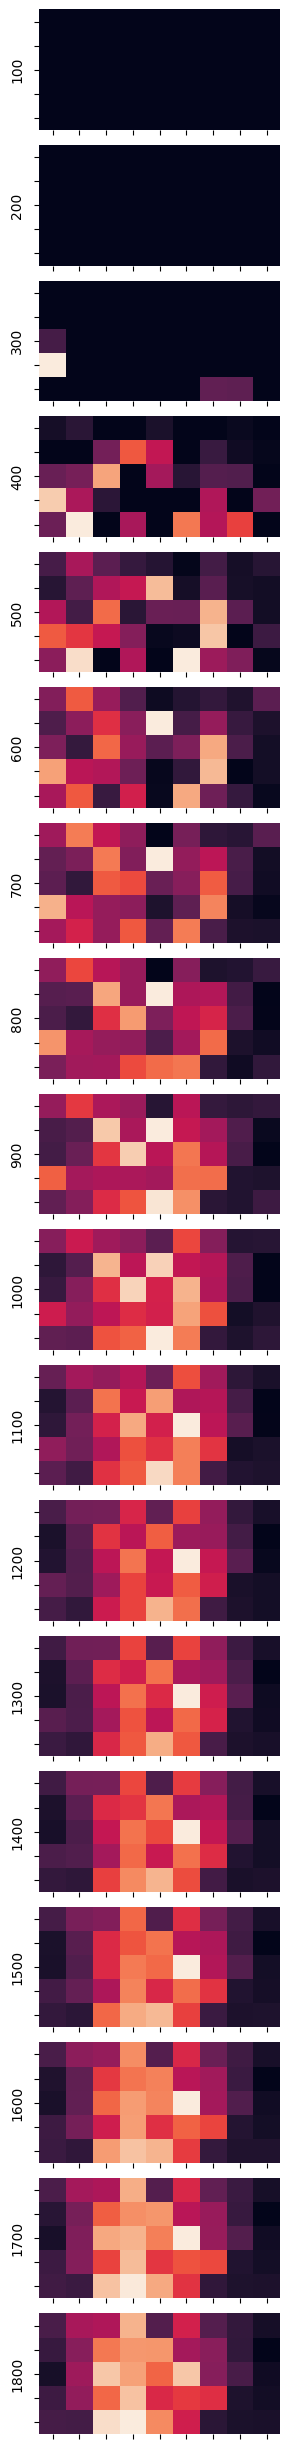

In [20]:
fluo_traces = data_filtered.pivot(index='nucleus_id', columns='time', values=['fluo'])
fluo_traces['ap_registered'] = data_filtered.pivot(index='nucleus_id', columns='time', values=['ap_registered']).mean(axis=1)
fluo_traces['yPos'] = data_filtered.pivot(index='nucleus_id', columns='time', values=['yPos']).mean(axis=1)
fluo_traces = fluo_traces.fillna(0)
fluo_traces.reset_index(inplace=True)
fluo_traces = fluo_traces[(fluo_traces['ap_registered'] >= 0.42) & (fluo_traces['ap_registered'] <= 0.57)]

fig, axes = plt.subplots(len(range(100, 1801, 100)), 1, figsize=(3, 15/11*len(range(100, 1801, 100))))
axes = axes.flatten()
# Loop over the time points and plot in each subplot
for i, t in enumerate(range(100, 1801, 100)):
    #sns.scatterplot(data=fluo_traces, x="ap_registered", y="yPos", hue=fluo_traces['fluo'].iloc[:,:fluo_traces['fluo'].columns.tolist().index(t)+1].sum(axis=1), legend=False, ax=axes[0],s=20,alpha=0.75)
    #sns.scatterplot(data=fluo_traces, x="ap_registered", y="yPos", hue=fluo_traces['fluo'].iloc[:,fluo_traces['fluo'].columns.tolist().index(t)-3:fluo_traces['fluo'].columns.tolist().index(t)+1].sum(axis=1), legend=False, ax=axes[1],s=20,alpha=0.75)
    # bin the :index(t) fluo into 5x7 grid and plot a heatmap
    x_bins = np.linspace(0.46, 0.54, 10)
    y_bins = np.linspace(fluo_traces['yPos'].min(), fluo_traces['yPos'].max(), 6)
    fluo_traces['x_bin'] = pd.cut(fluo_traces['ap_registered'], bins=x_bins, labels=False)
    fluo_traces['y_bin'] = pd.cut(fluo_traces['yPos'], bins=y_bins, labels=False)
    #heatmap_data = fluo_traces.groupby(['x_bin', 'y_bin']).apply(lambda df: df['fluo'].iloc[:,:fluo_traces['fluo'].columns.tolist().index(t)+1].sum(axis=1).sum()).unstack().fillna(0)
    #sns.heatmap(heatmap_data.T, ax=axes[2], cbar=False)
    #axes[2].invert_yaxis()
    # Ensure heatmaps are oriented as 5 rows (y bins) x 7 cols (x bins)
    #n_rows = len(y_bins) - 1
    #n_cols = len(x_bins) - 1

    ## axes[2] uses heatmap_data.T (should be n_rows x n_cols)
    #hm = heatmap_data.T
    #xtick_pos = np.arange(hm.shape[1]) + 0.5
    #ytick_pos = np.arange(hm.shape[0]) + 0.5
    #x_labels = [f'{start:.3f}-{end:.3f}' for start, end in zip(x_bins[:-1], x_bins[1:])]
    #y_labels = [f'{int(start)}-{int(end)}' for start, end in zip(y_bins[:-1], y_bins[1:])]

    #axes[2].set_xticks(xtick_pos)
    #axes[2].set_xticklabels(x_labels, rotation=45, ha='right')
    #axes[2].set_yticks(ytick_pos)
    #axes[2].set_yticklabels(y_labels)
    #axes[2].set_title('5x7 Binned Heatmap')

    heatmap_data = fluo_traces.groupby(['x_bin', 'y_bin']).apply(lambda df: df['fluo'].iloc[:,:fluo_traces['fluo'].columns.tolist().index(t)+1].sum(axis=1).sum()).unstack().fillna(0)
    sns.heatmap(heatmap_data.T, ax=axes[i], cbar=False)
    axes[i].invert_yaxis()
    # Ensure heatmaps are oriented as 5 rows (y bins) x 7 cols (x bins)
    n_rows = len(y_bins) - 1
    n_cols = len(x_bins) - 1

    # axes[2] uses heatmap_data.T (should be n_rows x n_cols)
    hm = heatmap_data.T
    xtick_pos = np.arange(hm.shape[1]) + 0.5
    ytick_pos = np.arange(hm.shape[0]) + 0.5
    x_labels = [f'{start:.3f}-{end:.3f}' for start, end in zip(x_bins[:-1], x_bins[1:])]
    y_labels = [f'{int(start)}-{int(end)}' for start, end in zip(y_bins[:-1], y_bins[1:])]

    axes[i].set_xticks(xtick_pos)
    axes[i].set_xticklabels('')#x_labels, rotation=45, ha='right')
    axes[i].set_yticks(ytick_pos)
    axes[i].set_yticklabels('')#y_labels)
    axes[i].set_title('')
    axes[i].set_xlabel('')
    axes[i].set_ylabel(t)
                           

plt.tight_layout()

## Add global axis labels
#fig.text(0.5, 0.02, 'AP Registered', ha='center', fontsize=14)
#fig.text(0.02, 0.5, 'Y Position', va='center', rotation='vertical', fontsize=14)

plt.show()